In [1]:
# Cell 1: Install ViennaRNA
!pip install viennarna

# Verify installation
try:
    import RNA
    VIENNA_AVAILABLE = True
    print("✓ ViennaRNA loaded successfully")
except ImportError:
    VIENNA_AVAILABLE = False
    print("⚠ ViennaRNA not available, using heuristic stability function")
    print("  Install with: !pip install viennarna")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 45.0 MB/s eta 0:00:00
✓ ViennaRNA loaded successfully


In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Stability-Distillation Hypothesis Simulation
Simulates wet-dry cycles driving RNA sequence frequency convergence and the emergence of tRNA-like structures.

Run in Google Colab:
    !pip install viennarna
    then run this script.

Key mechanisms:
- Wet phase: Unstable sequences degrade based on thermal/acidic stress
- Dry phase: Frequent stable sequences ligate to form longer RNAs
- Nucleotide supplementation: Periodic monomer input from geothermal activity
- Stability difference amplification: Harsh conditions magnify stability disparities
"""

import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Try to import ViennaRNA for accurate stability calculation
try:
    import RNA
    VIENNA_AVAILABLE = True
    print("✓ ViennaRNA loaded successfully")
except ImportError:
    VIENNA_AVAILABLE = False
    print("⚠ ViennaRNA not available, using heuristic stability function")
    print("  Install with: !pip install viennarna")

# ============================================================================
# Part 1: Stability Calculation Functions
# ============================================================================

def calculate_stability_vienna(sequence, harshness=1.0):
    """
    Calculate RNA stability using ViennaRNA's minimum free energy (MFE).
    Directly uses MFE without length normalization - stable structures naturally have lower MFE.

    The harshness parameter amplifies stability differences:
    - harshness > 1.0: More extreme environment, stability differences magnified
    - harshness = 1.0: Normal environment
    - harshness < 1.0: Mild environment, stability differences reduced

    Args:
        sequence: RNA sequence string (A/U/G/C)
        harshness: Environmental harshness factor (amplifies stability differences)

    Returns:
        stability: normalized score 0-1 (higher = more stable)
        structure: dot-bracket secondary structure
        mfe: minimum free energy in kcal/mol
    """
    if len(sequence) < 4:
        return 0.2, "", 0

    try:
        fc = RNA.fold_compound(sequence)
        (ss, mfe) = fc.mfe()

        # Direct MFE usage - no length normalization!
        # MFE range: 0 to -50 kcal/mol (more negative = more stable)
        # Map to 0-1: -50 -> 1.0, 0 -> 0.0
        raw_stability = -mfe / 50.0
        stability = min(0.95, max(0.05, raw_stability))

        # Apply harshness: amplify the difference from baseline (0.5)
        # This makes stable sequences more stable, unstable ones more unstable
        if harshness != 1.0:
            # Center around 0.5, then stretch
            deviation = stability - 0.5
            stability = 0.5 + deviation * harshness
            stability = min(0.95, max(0.05, stability))

        return stability, ss, mfe

    except Exception as e:
        return calculate_stability_heuristic(sequence, harshness), "", 0


def calculate_stability_heuristic(sequence, harshness=1.0):
    """
    Heuristic stability calculation based on structural formation capability.
    Focuses on complementarity and stem-loop potential, not GC content bias.

    Args:
        sequence: RNA sequence string
        harshness: Environmental harshness factor

    Returns:
        stability: normalized score 0-1
    """
    if len(sequence) < 4:
        return 0.2

    comp_map = {'A': 'U', 'U': 'A', 'G': 'C', 'C': 'G'}

    # 1. Self-complementarity detection (most important for stable folding)
    half_len = len(sequence) // 2
    complement_score = 0
    if half_len >= 1:
        first_half = sequence[:half_len]
        second_half_rev = sequence[half_len:][::-1]

        matches = 0
        for i in range(min(len(first_half), len(second_half_rev))):
            if comp_map.get(first_half[i], '') == second_half_rev[i]:
                matches += 1
        complement_score = matches / max(1, half_len)

    # 2. Local structure formation (ability to form hairpins and stems)
    structural_score = 0
    for i in range(len(sequence) - 3):
        for length in range(3, min(8, (len(sequence) - i) // 2)):
            left = sequence[i:i+length]
            right = sequence[i+length:i+2*length][::-1]

            if len(right) >= length:
                matches = 0
                for k in range(length):
                    if comp_map.get(left[k], '') == right[k]:
                        matches += 1
                pair_rate = matches / length
                if pair_rate > structural_score:
                    structural_score = pair_rate

    # 3. Base composition (reduced weight - structure matters more)
    gc_ratio = (sequence.count('G') + sequence.count('C')) / len(sequence)

    # 4. Stability = structural capability dominates
    # AU-rich sequences can be stable if they form good structures!
    stability = 0.1 + 0.5 * complement_score + 0.3 * structural_score + 0.1 * gc_ratio

    # 5. Long sequences with good structure get recognition
    if len(sequence) > 30 and structural_score > 0.5:
        stability = min(0.95, stability + 0.1)

    # Apply harshness: amplify stability differences
    if harshness != 1.0:
        deviation = stability - 0.5
        stability = 0.5 + deviation * harshness
        stability = min(0.95, max(0.05, stability))

    return stability


# Global variables for stability calculation
USE_VIENNA_GLOBAL = VIENNA_AVAILABLE
HARSHNESS_GLOBAL = 1.0

def get_stability(sequence):
    """
    Unified stability calculation interface.
    Uses global settings for ViennaRNA and harshness.

    Args:
        sequence: RNA sequence string

    Returns:
        stability: normalized score 0-1
    """
    if USE_VIENNA_GLOBAL and VIENNA_AVAILABLE and len(sequence) >= 4:
        stability, _, _ = calculate_stability_vienna(sequence, HARSHNESS_GLOBAL)
        return stability
    else:
        return calculate_stability_heuristic(sequence, HARSHNESS_GLOBAL)

# ============================================================================
# Part 2: Main Simulation Class
# ============================================================================

class StabilityDistillationSimulation:
    """
    Simulates the stability-distillation process for RNA sequence evolution.

    Key mechanisms:
    - Wet phase: Unstable sequences degrade (probability = 1 - stability^harshness)
    - Dry phase: Stable sequences serve as building blocks for ligation
    - Nucleotide supplementation: Periodic addition of monomers
    - Harshness: Environmental stress amplifies stability differences
    """

    def __init__(self,
                 initial_seq_length=6,
                 num_initial_sequences=200,
                 max_seq_length=150,
                 dry_growth_factor=1.3,
                 wet_degradation_strength=1.0,
                 ligation_base_prob=0.05,
                 supplementation_fraction=0.02,
                 initial_nucleotide_pool=1000,
                 harshness=1.0):
        """
        Initialize the simulation.

        Args:
            initial_seq_length: Length of randomly generated starting sequences
            num_initial_sequences: Number of initial sequences to generate
            max_seq_length: Maximum allowed sequence length (prevents unbounded growth)
            dry_growth_factor: Multiplication factor for copy numbers during dry phase
            wet_degradation_strength: Exponent controlling degradation strength (higher = more degradation)
            ligation_base_prob: Base probability for sequence ligation events
            supplementation_fraction: Fraction of INITIAL nucleotide pool to add as monomers each cycle
            initial_nucleotide_pool: Total number of ribonucleotide monomers available at start
            harshness: Environmental harshness factor (amplifies stability differences)
                      Higher values = more extreme conditions (hot, acidic)
                      Typical range: 0.5 (mild) to 2.0 (extreme)
        """
        self.max_seq_length = max_seq_length
        self.dry_growth_factor = dry_growth_factor
        self.wet_degradation_strength = wet_degradation_strength
        self.ligation_base_prob = ligation_base_prob
        self.supplementation_fraction = supplementation_fraction
        self.initial_nucleotide_pool = initial_nucleotide_pool
        self.harshness = harshness

        # Update global harshness for stability calculations
        global HARSHNESS_GLOBAL
        HARSHNESS_GLOBAL = harshness

        # Available nucleotides
        self.nucleotides = ['A', 'U', 'G', 'C']

        # Initialize sequence pool: generate random short sequences
        self.sequences = []
        for _ in range(num_initial_sequences):
            seq = ''.join(random.choice(self.nucleotides)
                         for _ in range(initial_seq_length))
            self.sequences.append(seq)

        # Frequency dictionary: sequence -> copy count
        self.frequencies = defaultdict(int)
        for seq in self.sequences:
            self.frequencies[seq] += 1

        # Add initial monomer pool
        for _ in range(initial_nucleotide_pool):
            monomer = random.choice(self.nucleotides)
            self.frequencies[monomer] += 1

        # Track the current longest sequence for each cycle
        self.current_longest_sequence = ""

        # History tracking for visualization
        self.history = {
            'entropy': [],
            'num_unique_sequences': [],
            'avg_length': [],
            'total_copies': [],
            'max_length': [],
            'longest_sequence': [],
            'top_sequences': [],
            'trna_candidates': []
        }

        print(f"Simulation initialized")
        print(f"  Initial sequence count: {len(self.sequences)}")
        print(f"  Unique sequences: {len(self.frequencies)}")
        print(f"  Initial nucleotide pool: {self.initial_nucleotide_pool}")
        print(f"  ViennaRNA available: {VIENNA_AVAILABLE}")
        print(f"  Environmental harshness: {self.harshness}")
        print(f"  Supplementation fraction: {self.supplementation_fraction * 100:.1f}% of initial pool per cycle")
        print(f"  Ligation base probability: {self.ligation_base_prob}")

    def calculate_entropy(self):
        """
        Calculate Shannon entropy of the current sequence distribution.
        Lower entropy = more concentrated distribution = more information.

        Returns:
            entropy: Shannon entropy in bits
        """
        total = sum(self.frequencies.values())
        if total == 0:
            return 0
        entropy = 0
        for count in self.frequencies.values():
            p = count / total
            if p > 0:
                entropy -= p * np.log2(p)
        return entropy

    def get_longest_sequence(self):
        """
        Find the current longest RNA sequence in the pool.

        Returns:
            longest_seq: The longest sequence string
            max_len: Length of the longest sequence
        """
        if not self.frequencies:
            return "", 0

        # Filter out monomers (length 1) when looking for longest
        sequences_only = [seq for seq in self.frequencies.keys() if len(seq) > 1]
        if not sequences_only:
            return "", 0

        longest_seq = max(sequences_only, key=len)
        return longest_seq, len(longest_seq)

    def add_nucleotide_supplementation(self):
        """
        Add fresh ribonucleotide monomers to the pool.
        This simulates continuous input from the geothermal environment.

        The supplementation is added as monomers, which can be used
        during the dry phase to form new RNA sequences.

        Supplementation is anchored to the INITIAL nucleotide pool size,
        providing consistent input regardless of population fluctuations.
        """
        if self.supplementation_fraction <= 0:
            return 0

        # Calculate monomers to add based on INITIAL pool size
        num_monomers = max(1, int(self.initial_nucleotide_pool * self.supplementation_fraction))

        # Add monomers with balanced composition
        for _ in range(num_monomers):
            monomer = random.choice(self.nucleotides)
            self.frequencies[monomer] += 1

        return num_monomers

    def is_trna_like(self, sequence):
        """
        Detect whether a sequence has tRNA-like structural potential.

        tRNA characteristics:
        - Can form cloverleaf structure with 3 or more stem-loop regions
        - Self-complementary regions allow stable folding
        - Typically 70-90 nucleotides in length

        Simplified detection: Look for 3 or more independent stem-loop regions
        where each stem has >=60% base pairing.

        Args:
            sequence: RNA sequence string

        Returns:
            True if the sequence exhibits tRNA-like characteristics
        """
        if len(sequence) < 30:
            return False

        # Base complementarity mapping
        comp_map = {'A': 'U', 'U': 'A', 'G': 'C', 'C': 'G'}
        stem_regions = []

        # Sliding window to detect potential stem-loop structures
        for i in range(len(sequence) - 4):
            for length in range(3, min(8, (len(sequence) - i) // 2)):
                left = sequence[i:i+length]
                right = sequence[i+length:i+2*length][::-1]

                # Calculate pairing rate for this potential stem
                matches = 0
                for j in range(length):
                    if j < len(left) and j < len(right):
                        if comp_map.get(left[j], '') == right[j]:
                            matches += 1

                pairing_rate = matches / length if length > 0 else 0
                if pairing_rate >= 0.6:  # 60% or more base pairing
                    stem_regions.append((i, i+2*length, pairing_rate))

        # Merge overlapping regions
        merged = []
        for region in sorted(stem_regions, key=lambda x: x[0]):
            if not merged or region[0] > merged[-1][1] + 5:
                merged.append(region)

        # tRNA-like structures need at least 3 independent stem-loop regions
        return len(merged) >= 3

    def wet_phase(self):
        """
        Wet phase: Unstable sequences degrade.

        Degradation probability depends on:
        1. Sequence stability (higher stability = lower degradation)
        2. Environmental harshness (amplifies stability differences)
        3. Degradation strength parameter

        In harsh environments (high temperature, acidic), the difference
        between stable and unstable sequences is magnified.
        """
        new_frequencies = defaultdict(int)

        for seq, count in self.frequencies.items():
            stability = get_stability(seq)

            # Survival probability increases with stability
            # Harshness amplifies the difference:
            # - Stable sequences become MORE likely to survive
            # - Unstable sequences become LESS likely to survive
            survival_prob = stability ** (self.wet_degradation_strength * self.harshness)
            survived = np.random.binomial(count, survival_prob)

            if survived > 0:
                new_frequencies[seq] = survived

        self.frequencies = new_frequencies

        # If everything went extinct, reintroduce some random sequences
        if len(self.frequencies) == 0:
            for _ in range(50):
                seq = ''.join(random.choice(self.nucleotides)
                             for _ in range(6))
                self.frequencies[seq] += 1

    def dry_phase(self):
        """
        Dry phase: Sequence ligation and growth.

        Key mechanism from the stability-distillation hypothesis:
        - Frequent sequences are more likely to collide and ligate
        - Ligation probability ∝ frequency(a) × frequency(b)
        - This allows stable short sequences to serve as "stepping stones"
          for building longer, potentially more stable sequences.
        """
        total = sum(self.frequencies.values())
        if total == 0:
            return

        # Calculate frequency ratio for each sequence
        freq_ratio = {seq: count/total for seq, count in self.frequencies.items()}

        # Generate new sequences via ligation
        new_sequences = []
        seq_list = list(self.frequencies.keys())

        # Generate approximately 30% of current population as new ligation products
        num_ligations = int(total * 0.3)

        for _ in range(num_ligations):
            if len(seq_list) < 2:
                break

            # Weighted selection based on frequency
            weights = [freq_ratio.get(seq, 0) for seq in seq_list]
            if sum(weights) == 0:
                break

            # Select two sequences to ligate, weighted by their frequencies
            a = np.random.choice(seq_list, p=weights)
            b = np.random.choice(seq_list, p=weights)

            # Ligation probability is proportional to the product of their frequencies
            # This captures the "collision probability" concept
            p_ligate = self.ligation_base_prob * (freq_ratio[a] * freq_ratio[b] * 100)
            p_ligate = min(0.8, p_ligate)

            if random.random() < p_ligate:
                new_seq = a + b
                if len(new_seq) <= self.max_seq_length:
                    new_sequences.append(new_seq)

        # Add newly ligated sequences to the pool
        for seq in new_sequences:
            self.frequencies[seq] += 1

        # All sequences grow during dry phase (general polymerization)
        for seq in list(self.frequencies.keys()):
            growth = np.random.poisson(self.dry_growth_factor - 1)
            if growth > 0:
                self.frequencies[seq] += growth

    def step(self, cycle_number):
        """
        Execute one complete wet-dry cycle.

        Order:
        1. Wet phase: Degradation of unstable sequences
        2. Add fresh nucleotide supplementation (simulating geothermal input)
        3. Dry phase: Ligation and growth

        Args:
            cycle_number: Current cycle number (for logging)
        """
        # Step 1: Wet phase - degradation
        self.wet_phase()

        # Step 2: Add fresh nucleotide supplementation
        monomers_added = self.add_nucleotide_supplementation()

        # Step 3: Dry phase - ligation and growth
        self.dry_phase()

        # Track current longest sequence
        longest_seq, max_len = self.get_longest_sequence()
        self.current_longest_sequence = longest_seq

        # Print current longest sequence
        if longest_seq:
            display_seq = longest_seq[:50] + '...' if len(longest_seq) > 50 else longest_seq
            print(f"  Cycle {cycle_number:3d}: Longest RNA = {display_seq} (length={max_len})")

        return monomers_added

    def run(self, num_cycles=50, record_interval=5):
        """
        Run the simulation for a specified number of cycles.

        Args:
            num_cycles: Number of wet-dry cycles to simulate
            record_interval: How often to record statistics (cycles between records)
        """
        print(f"\nStarting simulation: {num_cycles} wet-dry cycles...")
        print("-" * 70)

        for cycle in range(num_cycles):
            monomers_added = self.step(cycle)

            # Record statistics at specified intervals
            if cycle % record_interval == 0 or cycle == num_cycles - 1:
                entropy = self.calculate_entropy()
                num_unique = len(self.frequencies)
                total = sum(self.frequencies.values())

                # Calculate average sequence length (excluding monomers)
                seq_lengths = [len(seq) for seq in self.frequencies.keys() if len(seq) > 1]
                avg_len = np.mean(seq_lengths) if seq_lengths else 0

                # Get current max length
                _, max_len = self.get_longest_sequence()

                # Get top 5 sequences by frequency
                top_seqs = Counter(self.frequencies).most_common(5)

                # Detect tRNA-like candidates
                trna_candidates = []
                for seq in list(self.frequencies.keys())[:50]:
                    if self.is_trna_like(seq) and self.frequencies[seq] > 1:
                        trna_candidates.append(seq)

                # Store history
                self.history['entropy'].append(entropy)
                self.history['num_unique_sequences'].append(num_unique)
                self.history['avg_length'].append(avg_len)
                self.history['total_copies'].append(total)
                self.history['max_length'].append(max_len)
                self.history['longest_sequence'].append(self.current_longest_sequence)
                self.history['top_sequences'].append(top_seqs)
                self.history['trna_candidates'].append(trna_candidates)

                print(f"  [Record] Cycle {cycle:3d}: Entropy={entropy:.3f} | Unique={num_unique:4d} | "
                      f"Total copies={total:6d} | Avg len={avg_len:.1f} | Max len={max_len} | "
                      f"tRNA candidates={len(trna_candidates)}")
                print()

        print("-" * 70)
        print("Simulation complete!")

    def plot_results(self):
        """
        Generate visualization plots showing key metrics over time.
        """
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # Generate x-axis values
        cycles = np.arange(len(self.history['entropy']))
        # Scale to approximate actual cycle numbers (if record_interval was 5)
        cycles_scaled = cycles * 5
        if len(cycles_scaled) < len(self.history['entropy']):
            cycles_scaled = cycles

        # Plot 1: Shannon entropy
        ax1 = axes[0, 0]
        ax1.plot(cycles_scaled, self.history['entropy'], 'b-o', linewidth=2, markersize=4)
        ax1.set_xlabel('Wet-dry cycles')
        ax1.set_ylabel('Shannon entropy (bits)')
        ax1.set_title('Entropy Decrease = Information Accumulation')
        ax1.grid(True, alpha=0.3)

        # Plot 2: Number of unique sequences
        ax2 = axes[0, 1]
        ax2.plot(cycles_scaled, self.history['num_unique_sequences'], 'r-s', linewidth=2, markersize=4)
        ax2.set_xlabel('Wet-dry cycles')
        ax2.set_ylabel('Number of unique sequences')
        ax2.set_title('Sequence Diversity')
        ax2.grid(True, alpha=0.3)

        # Plot 3: Total copy number
        ax3 = axes[0, 2]
        ax3.plot(cycles_scaled, self.history['total_copies'], 'g-^', linewidth=2, markersize=4)
        ax3.set_xlabel('Wet-dry cycles')
        ax3.set_ylabel('Total copy number')
        ax3.set_title(f'Total RNA Copies (Supp: {self.supplementation_fraction*100:.1f}%/cycle)')
        ax3.grid(True, alpha=0.3)

        # Plot 4: Maximum sequence length
        ax4 = axes[1, 0]
        ax4.plot(cycles_scaled, self.history['max_length'], 'c-d', linewidth=2, markersize=4)
        ax4.set_xlabel('Wet-dry cycles')
        ax4.set_ylabel('Maximum sequence length (nt)')
        ax4.set_title('Maximum Length Growth = Distillation Effect')
        ax4.grid(True, alpha=0.3)

        # Plot 5: Number of tRNA-like candidates
        ax5 = axes[1, 1]
        trna_counts = [len(t) for t in self.history['trna_candidates']]
        ax5.bar(cycles_scaled, trna_counts, color='purple', alpha=0.7)
        ax5.set_xlabel('Wet-dry cycles')
        ax5.set_ylabel('Number of tRNA-like candidates')
        ax5.set_title('Emergence of tRNA-like Structures')
        ax5.grid(True, alpha=0.3)

        # Plot 6: Entropy vs Total copies (phase space)
        ax6 = axes[1, 2]
        ax6.scatter(self.history['total_copies'], self.history['entropy'],
                   c=cycles_scaled, cmap='viridis', s=50, alpha=0.7)
        ax6.set_xlabel('Total copy number')
        ax6.set_ylabel('Shannon entropy')
        ax6.set_title('Phase Space: Entropy vs. Population Size')
        ax6.grid(True, alpha=0.3)
        cbar = plt.colorbar(ax6.collections[0], ax=ax6)
        cbar.set_label('Cycle number')

        plt.tight_layout()
        plt.savefig('stability_distillation_results.png', dpi=150)
        plt.show()

    def print_top_sequences(self, n=15):
        """
        Print the most frequent sequences with their stability scores.

        Args:
            n: Number of top sequences to display
        """
        print("\n" + "=" * 80)
        print(f"Top {n} Most Frequent Sequences")
        print("=" * 80)

        # Filter out monomers for top sequences display
        sequences_only = {seq: count for seq, count in self.frequencies.items() if len(seq) > 1}
        if not sequences_only:
            print("  No sequences longer than 1 nt found.")
            return

        top = Counter(sequences_only).most_common(n)
        for i, (seq, count) in enumerate(top, 1):
            stability = get_stability(seq)
            trna_flag = "★ tRNA-like" if self.is_trna_like(seq) else ""
            display_seq = seq[:50] + '...' if len(seq) > 50 else seq
            print(f"{i:2d}. [{count:5d}] {display_seq:55s} "
                  f"(stability={stability:.3f}) {trna_flag}")

        # Display all discovered tRNA-like sequences
        all_trna = [seq for seq in self.frequencies.keys() if self.is_trna_like(seq)]
        if all_trna:
            print("\n" + "=" * 80)
            print(f"Discovered tRNA-like Structures ({len(all_trna)} sequences)")
            print("=" * 80)
            for seq in all_trna[:5]:
                stability = get_stability(seq)
                print(f"\n  Sequence: {seq[:70]}")
                print(f"  Length: {len(seq)} nt, Stability: {stability:.3f}")

                # Show predicted secondary structure if ViennaRNA is available
                if VIENNA_AVAILABLE and len(seq) <= 100:
                    try:
                        fc = RNA.fold_compound(seq)
                        (ss, mfe) = fc.mfe()
                        print(f"  Predicted structure: {ss[:70]}")
                        print(f"  Minimum free energy: {mfe:.1f} kcal/mol")
                    except:
                        pass
            if len(all_trna) > 5:
                print(f"\n  ... and {len(all_trna) - 5} more")

        print()

# ============================================================================
# Part 3: Main Program with Configurable Parameters
# ============================================================================

def run_demo(stability_method='vienna',
             initial_nucleotide_pool=1000,
             num_cycles=50,
             supplementation_fraction=0.02,
             ligation_prob=0.05,
             harshness=1.0):
    """
    Run the stability-distillation simulation demo.

    Args:
        stability_method: Method for stability calculation
                         'vienna' - use ViennaRNA (requires installation)
                         'heuristic' - use built-in heuristic function
        initial_nucleotide_pool: Total number of ribonucleotide monomers at start
        num_cycles: Number of wet-dry cycles to simulate
        supplementation_fraction: Fraction of INITIAL pool to add as monomers each cycle
        ligation_prob: Base probability for sequence ligation during dry phase
                      Higher values = more frequent ligation events
        harshness: Environmental harshness factor (amplifies stability differences)
                  Higher values = more extreme conditions (hot, acidic)
                  Range: 0.5 (mild) to 2.0 (extreme), default: 1.0
    """
    global USE_VIENNA_GLOBAL, HARSHNESS_GLOBAL

    print("=" * 80)
    print("     Stability-Distillation Hypothesis Simulation")
    print("     Simulating wet-dry cycles driving RNA sequence convergence")
    print("=" * 80)

    # Display configuration
    print(f"\nConfiguration:")
    print(f"  Stability calculation method: {stability_method.upper()}")
    print(f"  Initial nucleotide pool: {initial_nucleotide_pool} monomers")
    print(f"  Number of cycles: {num_cycles}")
    print(f"  Supplementation fraction: {supplementation_fraction * 100:.1f}% of initial pool per cycle")
    print(f"  Ligation probability (base): {ligation_prob}")
    print(f"  Environmental harshness: {harshness}")
    print(f"    (Higher = more extreme conditions, stability differences amplified)")

    # Determine which stability method to use
    if stability_method.lower() == 'vienna':
        if VIENNA_AVAILABLE:
            USE_VIENNA_GLOBAL = True
            print(f"\n  ✓ Using ViennaRNA for stability calculations")
        else:
            USE_VIENNA_GLOBAL = False
            print(f"\n  ✗ ViennaRNA requested but not available!")
            print(f"    Falling back to heuristic method.")
            print(f"    Install with: !pip install viennarna")
    else:
        USE_VIENNA_GLOBAL = False
        print(f"\n  Using heuristic stability calculation")

    HARSHNESS_GLOBAL = harshness
    print()

    # Create simulator with parameters
    sim = StabilityDistillationSimulation(
        initial_seq_length=6,
        num_initial_sequences=200,
        max_seq_length=150,
        dry_growth_factor=1.3,
        wet_degradation_strength=1.0,
        ligation_base_prob=ligation_prob,
        supplementation_fraction=supplementation_fraction,
        initial_nucleotide_pool=initial_nucleotide_pool,
        harshness=harshness
    )

    # Run simulation
    sim.run(num_cycles=num_cycles, record_interval=5)

    # Visualize results
    sim.plot_results()

    # Print top sequences
    sim.print_top_sequences(n=15)

    # Summary statistics
    print("\n" + "=" * 80)
    print("Simulation Summary")
    print("=" * 80)

    # Filter out monomers for summary
    sequences_only = {seq: count for seq, count in sim.frequencies.items() if len(seq) > 1}

    print(f"Final unique sequences (length>1): {len(sequences_only)}")
    print(f"Final total copies (all): {sum(sim.frequencies.values())}")
    print(f"Final entropy: {sim.calculate_entropy():.3f} bits")

    if sequences_only:
        seq_lengths = [len(s) for s in sequences_only.keys()]
        print(f"Sequence length range: {min(seq_lengths)} - {max(seq_lengths)} nt")
        print(f"Average sequence length: {np.mean(seq_lengths):.1f} nt")

    # Check if we achieved significant convergence
    if sim.history['entropy']:
        initial_entropy = sim.history['entropy'][0]
        final_entropy = sim.history['entropy'][-1]
        entropy_reduction = initial_entropy - final_entropy
        print(f"\nEntropy reduction: {entropy_reduction:.2f} bits (from {initial_entropy:.2f} to {final_entropy:.2f})")

        if entropy_reduction > 2:
            print("  ✓ Significant information accumulation observed!")
        elif entropy_reduction > 1:
            print("  ~ Moderate information accumulation observed.")
        else:
            print("  ⚠ Limited information accumulation. Try increasing cycles or adjusting parameters.")

    # Show longest sequence found
    longest_seq, max_len = sim.get_longest_sequence()
    if longest_seq:
        display_seq = longest_seq[:80] + '...' if len(longest_seq) > 80 else longest_seq
        print(f"\nLongest sequence discovered: {display_seq}")
        print(f"  Length: {max_len} nt")

    # Show tRNA-like sequences found
    trna_found = [seq for seq in sim.frequencies.keys() if sim.is_trna_like(seq)]
    if trna_found:
        print(f"\n★ tRNA-like sequences found: {len(trna_found)}")
        for seq in trna_found[:3]:
            print(f"    - {seq[:60]}... (len={len(seq)})")

# ============================================================================
# Run with different configurations
# ============================================================================



✓ ViennaRNA loaded successfully


     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: HEURISTIC
  Initial nucleotide pool: 10000 monomers
  Number of cycles: 300
  Supplementation fraction: 0.1% of initial pool per cycle
  Ligation probability (base): 0.1
  Environmental harshness: 0.2
    (Higher = more extreme conditions, stability differences amplified)

  Using heuristic stability calculation

Simulation initialized
  Initial sequence count: 200
  Unique sequences: 200
  Initial nucleotide pool: 10000
  ViennaRNA available: True
  Environmental harshness: 0.2
  Supplementation fraction: 0.1% of initial pool per cycle
  Ligation base probability: 0.1

Starting simulation: 300 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = AUAAUA (length=6)
  [Record] Cycle   0: Entropy=3.181 | Unique= 193 | Total copies=  8710 | Avg len=5.7 | Max len=6 | tR

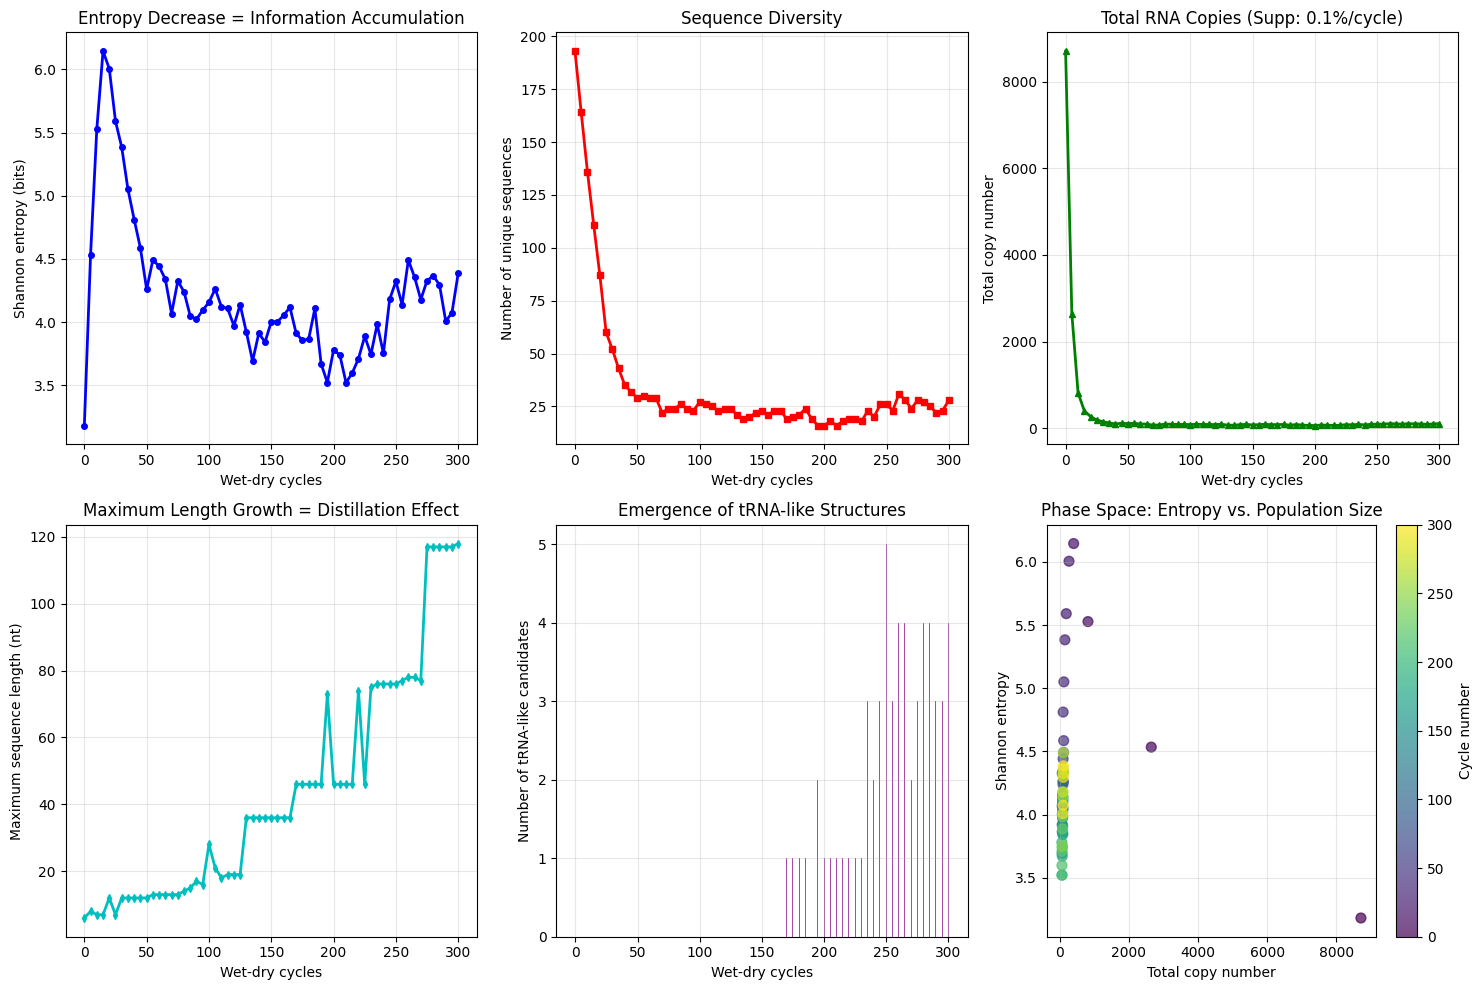


Top 15 Most Frequent Sequences
 1. [    6] CGUGGUUCACGUUCACCUGAGCGCUGCAAAAUUGAUCCCUGGUUCACGUU...   (stability=0.540) ★ tRNA-like
 2. [    5] GUGGUUCACGUUCACCUGAGCGCUGCAAAAUUGAUCCCUGGUUCACGUUC...   (stability=0.543) ★ tRNA-like
 3. [    5] CGUGGUUCACGUUCACCUGAGCGCUGCAAAAUUGAUCCCUGGUUCACGUU...   (stability=0.536) ★ tRNA-like
 4. [    4] UGGUUCACGUUCACCUGAGCGCUGCAAAAUUGAUCCU                   (stability=0.554) 
 5. [    4] UUGGUUCACGUUCACCUGAGCGCUGCAAAAUUGAUCCU                  (stability=0.541) 
 6. [    4] GGUGGUUCACGUUCACCUGAGCGCUGCAAAAUUGAUCCC                 (stability=0.542) 
 7. [    4] UGUGGUUCACGUUCACCUGAGCGCUGCAAAAUUGAUCCUG                (stability=0.540) 
 8. [    4] CU                                                      (stability=0.200) 
 9. [    3] UGGUUCACGUUCACCUGAGCGCUGCAAAAUUGAUCCUG                  (stability=0.542) 
10. [    3] UUGGUUCACGUUCACCUGAGCGCUGCAAAAUUGAUCCUUUUC              (stability=0.528) 
11. [    3] UUGGUUCACGUUCACCUGAGCGCUGCAAAAUUGAUCCUC              

In [15]:
if __name__ == "__main__":
    # ================================================================
    # USER CONFIGURABLE PARAMETERS
    # ================================================================
    #
    # 1. STABILITY_METHOD: Method for calculating RNA stability
    #    - 'vienna'    : Use ViennaRNA (requires !pip install viennarna)
    #    - 'heuristic' : Use built-in GC content + complementarity heuristic
    #
    # 2. INITIAL_NUCLEOTIDE_POOL: Total ribonucleotide monomers at start
    #    - Default: 1000
    #    - This anchors the supplementation calculation
    #
    # 3. NUM_CYCLES: Number of wet-dry cycles to simulate
    #    - Default: 50
    #    - Increase for more evolution time
    #
    # 4. SUPPLEMENTATION_FRACTION: Fraction of INITIAL pool added each cycle
    #    - Default: 0.02 (2%)
    #    - 0.00 = no supplementation (closed system)
    #    - 0.01 = 1% of initial pool per cycle
    #    - 0.02 = 2% of initial pool per cycle (recommended)
    #    - 0.05 = 5% of initial pool per cycle
    #
    # 5. LIGATION_PROB: Base probability for sequence ligation
    #    - Default: 0.05
    #    - Higher values = more frequent ligation events
    #    - Increase if sequences aren't getting longer
    #
    # 6. HARSHNESS: Environmental harshness (amplifies stability differences)
    #    - Default: 1.0
    #    - 0.5 = Mild environment (small stability differences)
    #    - 1.0 = Normal environment
    #    - 1.5 = Harsh environment (hot, acidic)
    #    - 2.0 = Extreme environment (large stability differences)
    #    - Higher harshness = faster selection but may lose diversity
    #
    # ================================================================

    # --- EDIT THESE PARAMETERS ---
    STABILITY_METHOD = 'heuristic'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 10000           # Total monomers at start
    NUM_CYCLES = 300                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.001          # 2% of initial pool per cycle
    LIGATION_PROB = 0.1                     # Base ligation probability
    HARSHNESS = 0.2                          # Environmental harshness
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        harshness=HARSHNESS
    )

     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: VIENNA
  Initial nucleotide pool: 10000 monomers
  Number of cycles: 1000
  Supplementation fraction: 0.0% of initial pool per cycle
  Ligation probability (base): 0.15
  Environmental harshness: 0.1
    (Higher = more extreme conditions, stability differences amplified)

  ✓ Using ViennaRNA for stability calculations

Simulation initialized
  Initial sequence count: 200
  Unique sequences: 202
  Initial nucleotide pool: 10000
  ViennaRNA available: True
  Environmental harshness: 0.1
  Supplementation fraction: 0.0% of initial pool per cycle
  Ligation base probability: 0.15

Starting simulation: 1000 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = GCAUUU (length=6)
  [Record] Cycle   0: Entropy=3.322 | Unique= 206 | Total copies= 10734 | Avg len=5.7 | Max le

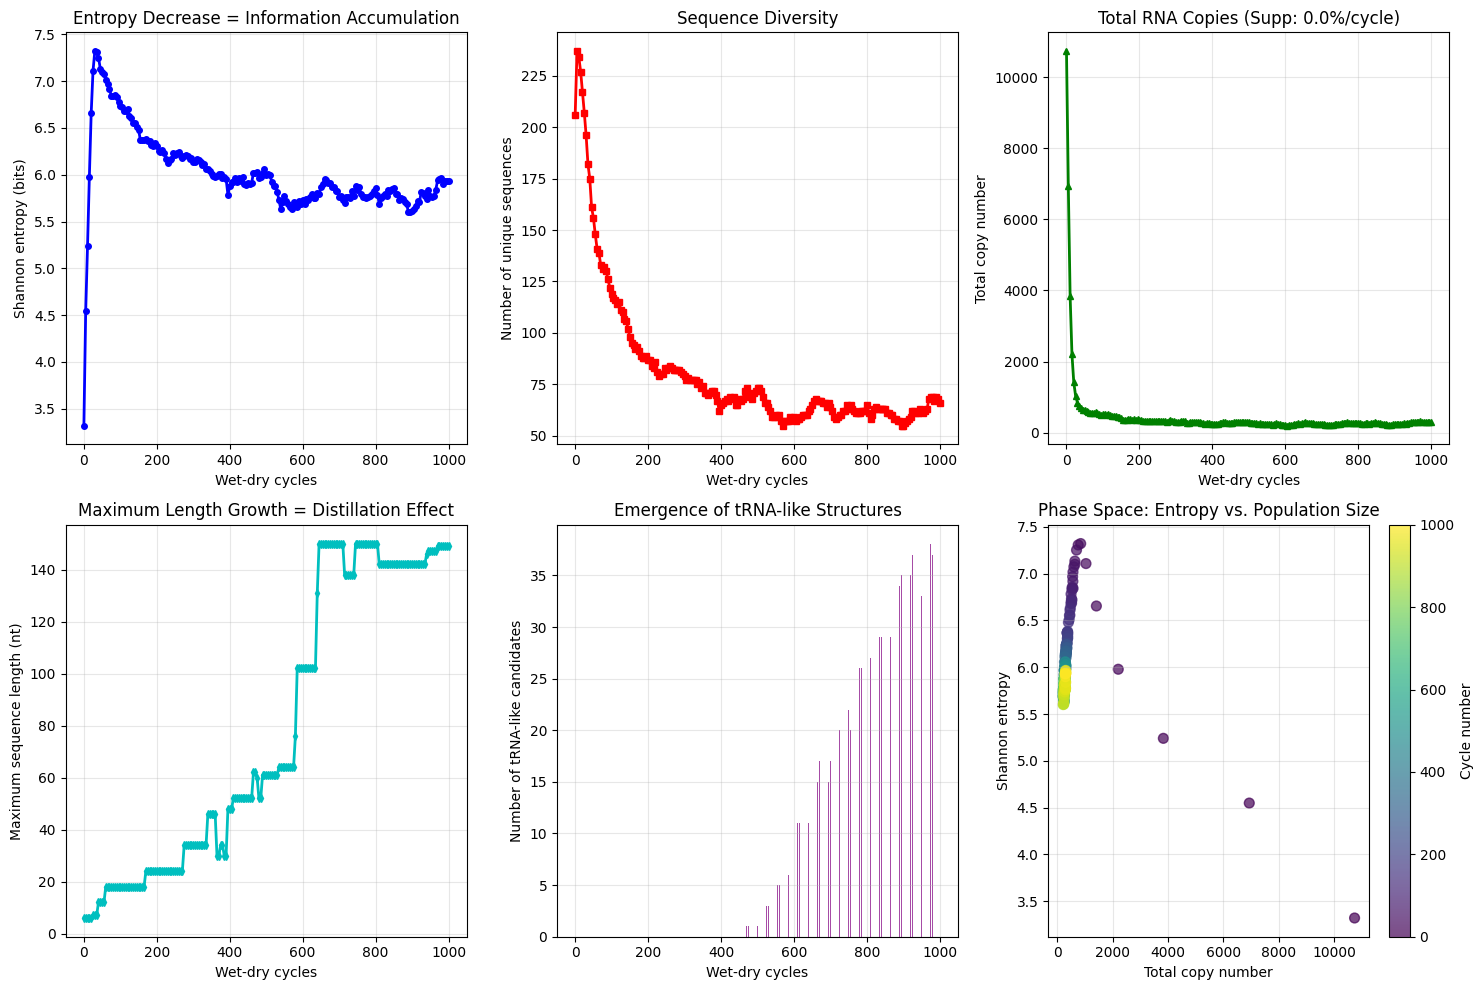


Top 15 Most Frequent Sequences
 1. [    9] CCUUCA                                                  (stability=0.455) 
 2. [    8] GCAUACCCUUUUCAUCCGCGUCCGCGUCCCCAGGUUCAA                 (stability=0.457) ★ tRNA-like
 3. [    7] GCGCAGCAGCUCAUGACGGUCCAUUCGCCCGUCUGAGAAUUAGCUUGACC...   (stability=0.514) ★ tRNA-like
 4. [    7] UGAAUCCUGGGAUAAGCUCUGAAUCGAUACUUUGAAUCGCAGUGUCCUAG...   (stability=0.525) ★ tRNA-like
 5. [    7] CCUUCAGCUUGACCAUAGUCGGAUGACGGCGCAGCAGCUCUCGCAUAAUG...   (stability=0.533) ★ tRNA-like
 6. [    7] GCCUUCAUGGGAUCCAGAUAUGACGGUCCAUUCGCCCGUCUGAGAAUUAG...   (stability=0.502) ★ tRNA-like
 7. [    7] AUGACGGCGCAGCAGCUCUCGCAUAAUGCGGCUGCUAACGCGACCGCGUC...   (stability=0.526) ★ tRNA-like
 8. [    7] CGCGACAUGCGGCCCAGUCCCCGUCUGAGCUUGACCAUGUCCUAGUCCUA...   (stability=0.514) ★ tRNA-like
 9. [    6] CGCAUAAUGCGGCUGCUAAUGAAUCCUGGGAUAAGCUCGUCUGAGCUUGA...   (stability=0.532) ★ tRNA-like
10. [    6] CCUUCAGCUUGACCAUAGUCGG                                  (stability=0.455) 
11. [    6

In [19]:
if __name__ == "__main__":
    # ================================================================
    # USER CONFIGURABLE PARAMETERS
    # ================================================================
    #
    # 1. STABILITY_METHOD: Method for calculating RNA stability
    #    - 'vienna'    : Use ViennaRNA (requires !pip install viennarna)
    #    - 'heuristic' : Use built-in GC content + complementarity heuristic
    #
    # 2. INITIAL_NUCLEOTIDE_POOL: Total ribonucleotide monomers at start
    #    - Default: 1000
    #    - This anchors the supplementation calculation
    #
    # 3. NUM_CYCLES: Number of wet-dry cycles to simulate
    #    - Default: 50
    #    - Increase for more evolution time
    #
    # 4. SUPPLEMENTATION_FRACTION: Fraction of INITIAL pool added each cycle
    #    - Default: 0.02 (2%)
    #    - 0.00 = no supplementation (closed system)
    #    - 0.01 = 1% of initial pool per cycle
    #    - 0.02 = 2% of initial pool per cycle (recommended)
    #    - 0.05 = 5% of initial pool per cycle
    #
    # 5. LIGATION_PROB: Base probability for sequence ligation
    #    - Default: 0.05
    #    - Higher values = more frequent ligation events
    #    - Increase if sequences aren't getting longer
    #
    # 6. HARSHNESS: Environmental harshness (amplifies stability differences)
    #    - Default: 1.0
    #    - 0.5 = Mild environment (small stability differences)
    #    - 1.0 = Normal environment
    #    - 1.5 = Harsh environment (hot, acidic)
    #    - 2.0 = Extreme environment (large stability differences)
    #    - Higher harshness = faster selection but may lose diversity
    #
    # ================================================================

    # --- EDIT THESE PARAMETERS ---
    STABILITY_METHOD = 'vienna'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 10000           # Total monomers at start
    NUM_CYCLES = 1000                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.0001          # 2% of initial pool per cycle
    LIGATION_PROB = 0.15                     # Base ligation probability
    HARSHNESS = 0.1                          # Environmental harshness
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        harshness=HARSHNESS
    )

     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: HEURISTIC
  Initial nucleotide pool: 10000 monomers
  Number of cycles: 300
  Supplementation fraction: 2.0% of initial pool per cycle
  Ligation probability (base): 0.1
  Environmental harshness: 0.2
    (Higher = more extreme conditions, stability differences amplified)

  Using heuristic stability calculation

Simulation initialized
  Initial sequence count: 200
  Unique sequences: 200
  Initial nucleotide pool: 10000
  ViennaRNA available: True
  Environmental harshness: 0.2
  Supplementation fraction: 2.0% of initial pool per cycle
  Ligation base probability: 0.1

Starting simulation: 300 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = UUGUCC (length=6)
  [Record] Cycle   0: Entropy=3.175 | Unique= 190 | Total copies=  8936 | Avg len=5.7 | Max len=6 | tR

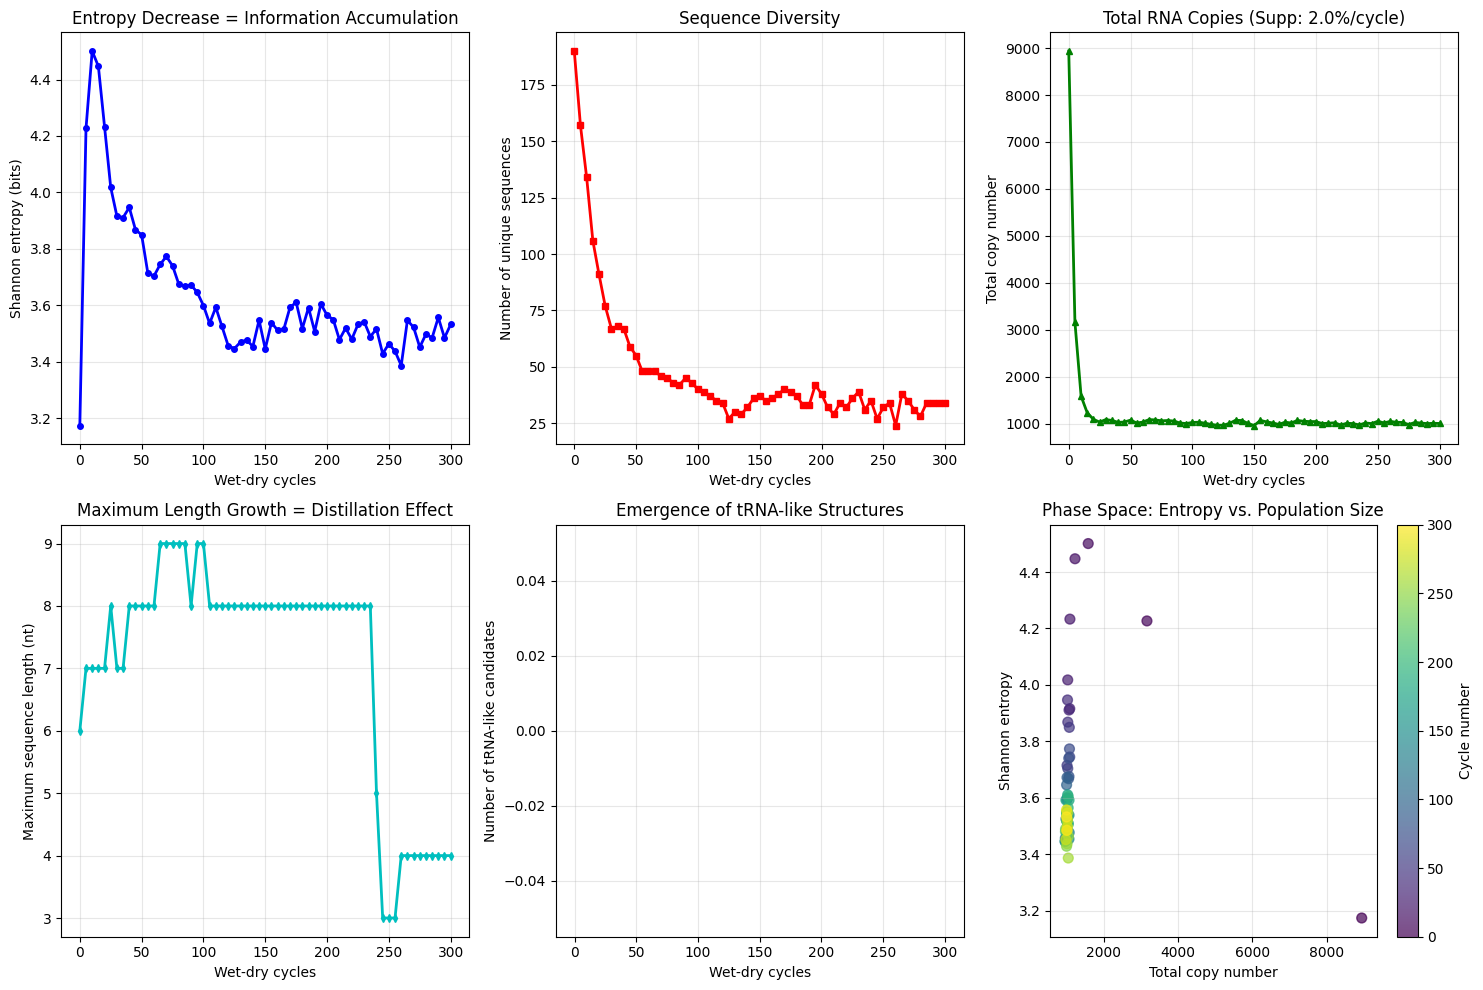


Top 15 Most Frequent Sequences
 1. [   22] CU                                                      (stability=0.200) 
 2. [   20] UU                                                      (stability=0.200) 
 3. [   20] CA                                                      (stability=0.200) 
 4. [   19] GU                                                      (stability=0.200) 
 5. [   18] UG                                                      (stability=0.200) 
 6. [   18] CG                                                      (stability=0.200) 
 7. [   17] AU                                                      (stability=0.200) 
 8. [   17] GC                                                      (stability=0.200) 
 9. [   16] CC                                                      (stability=0.200) 
10. [   14] UC                                                      (stability=0.200) 
11. [   13] AA                                                      (stability=0.200) 
12. [   13]

In [16]:
if __name__ == "__main__":
    # ================================================================
    # USER CONFIGURABLE PARAMETERS
    # ================================================================
    #
    # 1. STABILITY_METHOD: Method for calculating RNA stability
    #    - 'vienna'    : Use ViennaRNA (requires !pip install viennarna)
    #    - 'heuristic' : Use built-in GC content + complementarity heuristic
    #
    # 2. INITIAL_NUCLEOTIDE_POOL: Total ribonucleotide monomers at start
    #    - Default: 1000
    #    - This anchors the supplementation calculation
    #
    # 3. NUM_CYCLES: Number of wet-dry cycles to simulate
    #    - Default: 50
    #    - Increase for more evolution time
    #
    # 4. SUPPLEMENTATION_FRACTION: Fraction of INITIAL pool added each cycle
    #    - Default: 0.02 (2%)
    #    - 0.00 = no supplementation (closed system)
    #    - 0.01 = 1% of initial pool per cycle
    #    - 0.02 = 2% of initial pool per cycle (recommended)
    #    - 0.05 = 5% of initial pool per cycle
    #
    # 5. LIGATION_PROB: Base probability for sequence ligation
    #    - Default: 0.05
    #    - Higher values = more frequent ligation events
    #    - Increase if sequences aren't getting longer
    #
    # 6. HARSHNESS: Environmental harshness (amplifies stability differences)
    #    - Default: 1.0
    #    - 0.5 = Mild environment (small stability differences)
    #    - 1.0 = Normal environment
    #    - 1.5 = Harsh environment (hot, acidic)
    #    - 2.0 = Extreme environment (large stability differences)
    #    - Higher harshness = faster selection but may lose diversity
    #
    # ================================================================

    # --- EDIT THESE PARAMETERS ---
    STABILITY_METHOD = 'heuristic'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 10000           # Total monomers at start
    NUM_CYCLES = 300                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.02          # 2% of initial pool per cycle
    LIGATION_PROB = 0.1                     # Base ligation probability
    HARSHNESS = 0.2                          # Environmental harshness
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        harshness=HARSHNESS
    )

     Stability-Distillation Hypothesis Simulation
     Simulating wet-dry cycles driving RNA sequence convergence

Configuration:
  Stability calculation method: HEURISTIC
  Initial nucleotide pool: 10000 monomers
  Number of cycles: 300
  Supplementation fraction: 0.0% of initial pool per cycle
  Ligation probability (base): 0.1
  Environmental harshness: 0.8
    (Higher = more extreme conditions, stability differences amplified)

  Using heuristic stability calculation

Simulation initialized
  Initial sequence count: 200
  Unique sequences: 199
  Initial nucleotide pool: 10000
  ViennaRNA available: True
  Environmental harshness: 0.8
  Supplementation fraction: 0.0% of initial pool per cycle
  Ligation base probability: 0.1

Starting simulation: 300 wet-dry cycles...
----------------------------------------------------------------------
  Cycle   0: Longest RNA = UCAUCU (length=6)
  [Record] Cycle   0: Entropy=3.234 | Unique= 103 | Total copies=  3350 | Avg len=5.4 | Max len=6 | tR

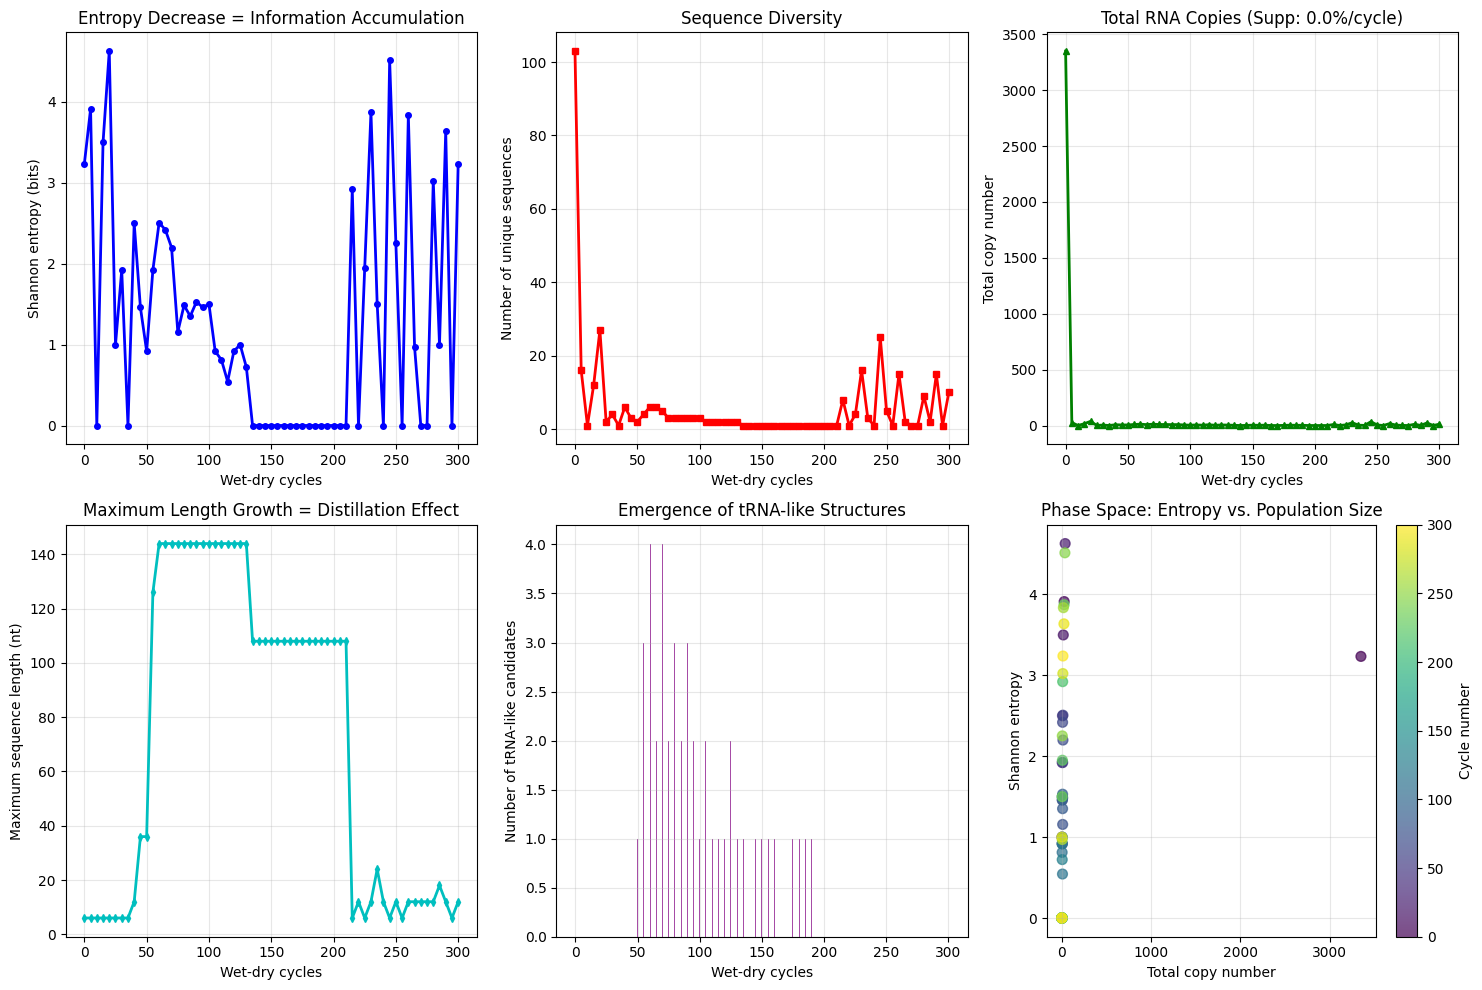


Top 15 Most Frequent Sequences
 1. [    2] CAGCGG                                                  (stability=0.513) 
 2. [    2] AGUACU                                                  (stability=0.607) 
 3. [    2] GCUGAC                                                  (stability=0.367) 
 4. [    1] CAUUAG                                                  (stability=0.340) 
 5. [    1] AACGCU                                                  (stability=0.487) 
 6. [    1] CUCAUA                                                  (stability=0.207) 
 7. [    1] AUAGUG                                                  (stability=0.207) 
 8. [    1] CGGCGU                                                  (stability=0.380) 
 9. [    1] CGCUUA                                                  (stability=0.220) 
10. [    1] CAGCGGCAUUAG                                            (stability=0.520) 


Simulation Summary
Final unique sequences (length>1): 10
Final total copies (all): 13
Final entr

In [21]:
if __name__ == "__main__":
    # ================================================================
    # USER CONFIGURABLE PARAMETERS
    # ================================================================
    #
    # 1. STABILITY_METHOD: Method for calculating RNA stability
    #    - 'vienna'    : Use ViennaRNA (requires !pip install viennarna)
    #    - 'heuristic' : Use built-in GC content + complementarity heuristic
    #
    # 2. INITIAL_NUCLEOTIDE_POOL: Total ribonucleotide monomers at start
    #    - Default: 1000
    #    - This anchors the supplementation calculation
    #
    # 3. NUM_CYCLES: Number of wet-dry cycles to simulate
    #    - Default: 50
    #    - Increase for more evolution time
    #
    # 4. SUPPLEMENTATION_FRACTION: Fraction of INITIAL pool added each cycle
    #    - Default: 0.02 (2%)
    #    - 0.00 = no supplementation (closed system)
    #    - 0.01 = 1% of initial pool per cycle
    #    - 0.02 = 2% of initial pool per cycle (recommended)
    #    - 0.05 = 5% of initial pool per cycle
    #
    # 5. LIGATION_PROB: Base probability for sequence ligation
    #    - Default: 0.05
    #    - Higher values = more frequent ligation events
    #    - Increase if sequences aren't getting longer
    #
    # 6. HARSHNESS: Environmental harshness (amplifies stability differences)
    #    - Default: 1.0
    #    - 0.5 = Mild environment (small stability differences)
    #    - 1.0 = Normal environment
    #    - 1.5 = Harsh environment (hot, acidic)
    #    - 2.0 = Extreme environment (large stability differences)
    #    - Higher harshness = faster selection but may lose diversity
    #
    # ================================================================

    # --- EDIT THESE PARAMETERS ---
    STABILITY_METHOD = 'heuristic'           # 'vienna' or 'heuristic'
    INITIAL_NUCLEOTIDE_POOL = 10000           # Total monomers at start
    NUM_CYCLES = 300                          # Number of wet-dry cycles
    SUPPLEMENTATION_FRACTION = 0.0          # 2% of initial pool per cycle
    LIGATION_PROB = 0.1                     # Base ligation probability
    HARSHNESS = 0.8                          # Environmental harshness
    # ----------------------------

    run_demo(
        stability_method=STABILITY_METHOD,
        initial_nucleotide_pool=INITIAL_NUCLEOTIDE_POOL,
        num_cycles=NUM_CYCLES,
        supplementation_fraction=SUPPLEMENTATION_FRACTION,
        ligation_prob=LIGATION_PROB,
        harshness=HARSHNESS
    )

In the origin of life, the appropriate intensity of environmental selection is crucial. If the environment is too harsh—such as excessively high temperature or extreme acidity—it may indiscriminately degrade almost any RNA sequence, including those with relatively stable structures, leaving little opportunity for complex molecules to accumulate. Conversely, an overly mild environment may fail to amplify the stability differences among sequences, resulting in a slow and inefficient distillation process.

Moderate supplementation of ribonucleotides plays an important role in maintaining the total copy number of RNA molecules. Periodic addition of "food" (monomers) provides the raw materials necessary for polymerization and ligation during dry phases, preventing the system from going extinct due to resource depletion. However, excessive supplementation may reduce evolutionary pressure. When monomers are too abundant, even unstable and functionally irrelevant sequences can survive and replicate, reducing the selective advantage of stable, structure-forming RNAs. In such a "resource-rich" environment, the system may remain trapped at the stage of short, random sequences without ever progressing toward longer, functional molecules like tRNA-like structures.

This phenomenon mirrors Darwinian natural selection: without sufficient selective pressure, evolution stalls; with too much pressure, diversity collapses. Only at the "Goldilocks" level of environmental stress and resource availability can the stability-distillation process effectively generate and accumulate informational macromolecules. This suggests that the origin of life is not merely a chemical inevitability but a finely balanced interplay between environmental conditions and molecular selection.
